# 3. Extract 2D Obstacles

Extracts 2D obstacle polygons from the BGT-labeled point clouds produced by **step 2.5**.

Each tile is voxelized, height-above-ground is computed, and connected components above
the height threshold are clustered into concave polygons.

**Input:** `bgt_labeled_{tilecode}.laz`  
**Output:** `obstacles_labeled_{tilecode}.geojson`

**Run this after step 2.5 (BGT Object Labeling).**

## Config

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('.').resolve()))

from config import LABELED_DIR, OBSTACLES_DIR, SETUP_TILECODES

tilecodes = SETUP_TILECODES

DIR_IN = str(LABELED_DIR / "bgt_labeled_")
DIR_OUT = OBSTACLES_DIR

CRS = 'EPSG:28992'
MAX_AREA = 20  # m² — drop oversized clusters (buildings, ground patches)

DIR_OUT.mkdir(parents=True, exist_ok=True)

## Imports

In [3]:
import numpy as np
import utils.obstacles_utils as obstacles_utils

## Extract clusters

In [4]:
clusters_dict = {}

for tilecode in tilecodes:
    laz_file = f"{DIR_IN}{tilecode}.laz"
    print(f"\n{tilecode}")
    clusters = obstacles_utils.cluster_obstacles(laz_file)
    clusters_dict[tilecode] = clusters
    print(f"  Detected obstacles: {len(clusters)}")


120300_489300
Loading LAZ...
Total points: 4252262
Building ground grid...
Computing height above ground...
Obstacle candidates: 2146743
Voxelizing...
Labeling components...
Components found: 1480
  Detected obstacles: 61

120300_488900
Loading LAZ...
Total points: 10130838
Building ground grid...
Computing height above ground...
Obstacle candidates: 6253635
Voxelizing...
Labeling components...
Components found: 6316
  Detected obstacles: 104

120700_489300
Loading LAZ...
Total points: 5066214
Building ground grid...
Computing height above ground...
Obstacle candidates: 2156763
Voxelizing...
Labeling components...
Components found: 1436
  Detected obstacles: 60

119900_489300
Loading LAZ...
Total points: 4996890
Building ground grid...
Computing height above ground...
Obstacle candidates: 2038525
Voxelizing...
Labeling components...
Components found: 1787
  Detected obstacles: 108

120300_489700
Loading LAZ...
Total points: 2497883
Building ground grid...
Computing height above ground

FileNotFoundError: [Errno 2] No such file or directory: 'data/output/labeled_pointcloud/bgt_labeled_121100_484900.laz'

## Save to GeoJSON

In [6]:
for tilecode, clusters in clusters_dict.items():
    gdf = obstacles_utils.clusters_to_concave_polygons(clusters, CRS)
    gdf['tilecode'] = tilecode
    gdf['area'] = gdf.area
    gdf = gdf[gdf.area < MAX_AREA]

    out_file = DIR_OUT / f"obstacles_labeled_{tilecode}.geojson"
    gdf.to_file(out_file, driver='GeoJSON')
    print(f"{tilecode}: {len(gdf)} obstacles -> {out_file}")

120300_489300: 49 obstacles -> data/output/obstacles/obstacles_labeled_120300_489300.geojson
120300_488900: 95 obstacles -> data/output/obstacles/obstacles_labeled_120300_488900.geojson
120700_489300: 46 obstacles -> data/output/obstacles/obstacles_labeled_120700_489300.geojson
119900_489300: 92 obstacles -> data/output/obstacles/obstacles_labeled_119900_489300.geojson
120300_489700: 40 obstacles -> data/output/obstacles/obstacles_labeled_120300_489700.geojson


## Optional: plot last tile

<Axes: >

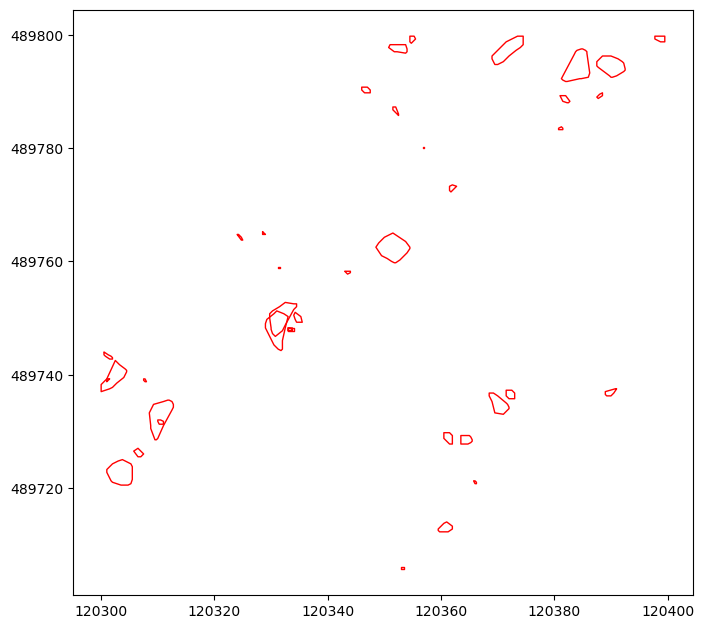

In [7]:
gdf.plot(edgecolor='red', facecolor='none', figsize=(8, 8))